In [1]:
from src.data_loader import DataManager
import src.analytics as analytics
import src.plotting as pl
import pandas as pd
import numpy as np

In [2]:
data_m = DataManager("../database_2026-03-04")
data_m.load_everything()

In [3]:
returns = data_m.get_daily_returns("close")

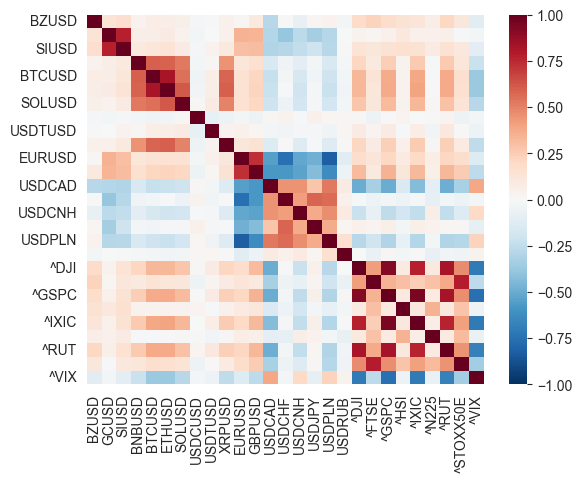

In [4]:
pear_cor, pear_pvals = analytics.correlations(returns, "pearson")
spear_cor, spear_pvals = analytics.correlations(returns, "spearman")
pl.heatmap_corr(pear_cor)

In [5]:
analytics.corr_score(pear_cor, pear_pvals)

^GSPC        8.023281
USDCAD       7.948879
^RUT         7.740882
^DJI         7.581100
^IXIC        7.517464
GBPUSD       7.242148
USDPLN       6.983015
EURUSD       6.754333
^VIX         6.554241
ETHUSD       6.151198
BTCUSD       6.011640
USDCNH       5.779183
^STOXX50E    5.585242
SOLUSD       5.045780
^FTSE        4.816160
SIUSD        4.540287
BNBUSD       4.400142
XRPUSD       4.239213
USDCHF       4.112556
GCUSD        3.436240
USDJPY       3.163355
^HSI         2.365757
BZUSD        2.278148
^N225        1.871149
USDTUSD      0.647484
USDRUB       0.601341
USDCUSD      0.083835
dtype: float64

In [6]:
analytics.corr_score(spear_cor, spear_pvals)

^GSPC        8.095499
USDCAD       8.042035
^RUT         8.008145
GBPUSD       7.723991
^IXIC        7.583615
^DJI         7.489057
USDPLN       7.214311
EURUSD       7.196454
^VIX         6.882824
ETHUSD       6.720758
BTCUSD       6.569126
USDCNH       6.271613
BNBUSD       5.903617
SOLUSD       5.681995
^STOXX50E    5.551855
USDCHF       5.367874
SIUSD        5.308067
XRPUSD       5.286064
^FTSE        4.640388
GCUSD        4.102382
USDJPY       3.260721
USDTUSD      2.379115
BZUSD        2.238112
^HSI         2.186818
^N225        1.809831
USDRUB       1.365414
USDCUSD      0.000000
dtype: float64

In [7]:
selected = ["^GSPC", "^RUT", "EURUSD", "BTCUSD", "GCUSD"]
returns_sel = returns[selected]

In [8]:
(pear_cor.loc[selected, selected]
 .style.format("{:.3f}")
 .apply(pl.highlight_significant(pear_pvals.loc[selected, selected]), axis=None))

,^GSPC,^RUT,EURUSD,BTCUSD,GCUSD
^GSPC,1.000,0.834,0.207,0.369,0.050
^RUT,0.834,1.000,0.216,0.378,0.062
EURUSD,0.207,0.216,1.000,0.155,0.349
BTCUSD,0.369,0.378,0.155,1.000,0.070
GCUSD,0.050,0.062,0.349,0.070,1.000


In [9]:
reg, reg_pvals = analytics.regression(returns_sel)
(reg.loc[selected, selected]
 .style.format("{:.3f}")
 .apply(pl.highlight_significant(reg_pvals.loc[selected, selected]), axis=None))

,^GSPC,^RUT,EURUSD,BTCUSD,GCUSD
^GSPC,1.000,1.152,0.089,1.101,0.052
^RUT,0.604,1.000,0.067,0.817,0.046
EURUSD,0.481,0.696,1.000,1.079,0.839
BTCUSD,0.124,0.175,0.022,1.000,0.024
GCUSD,0.049,0.083,0.146,0.204,1.000


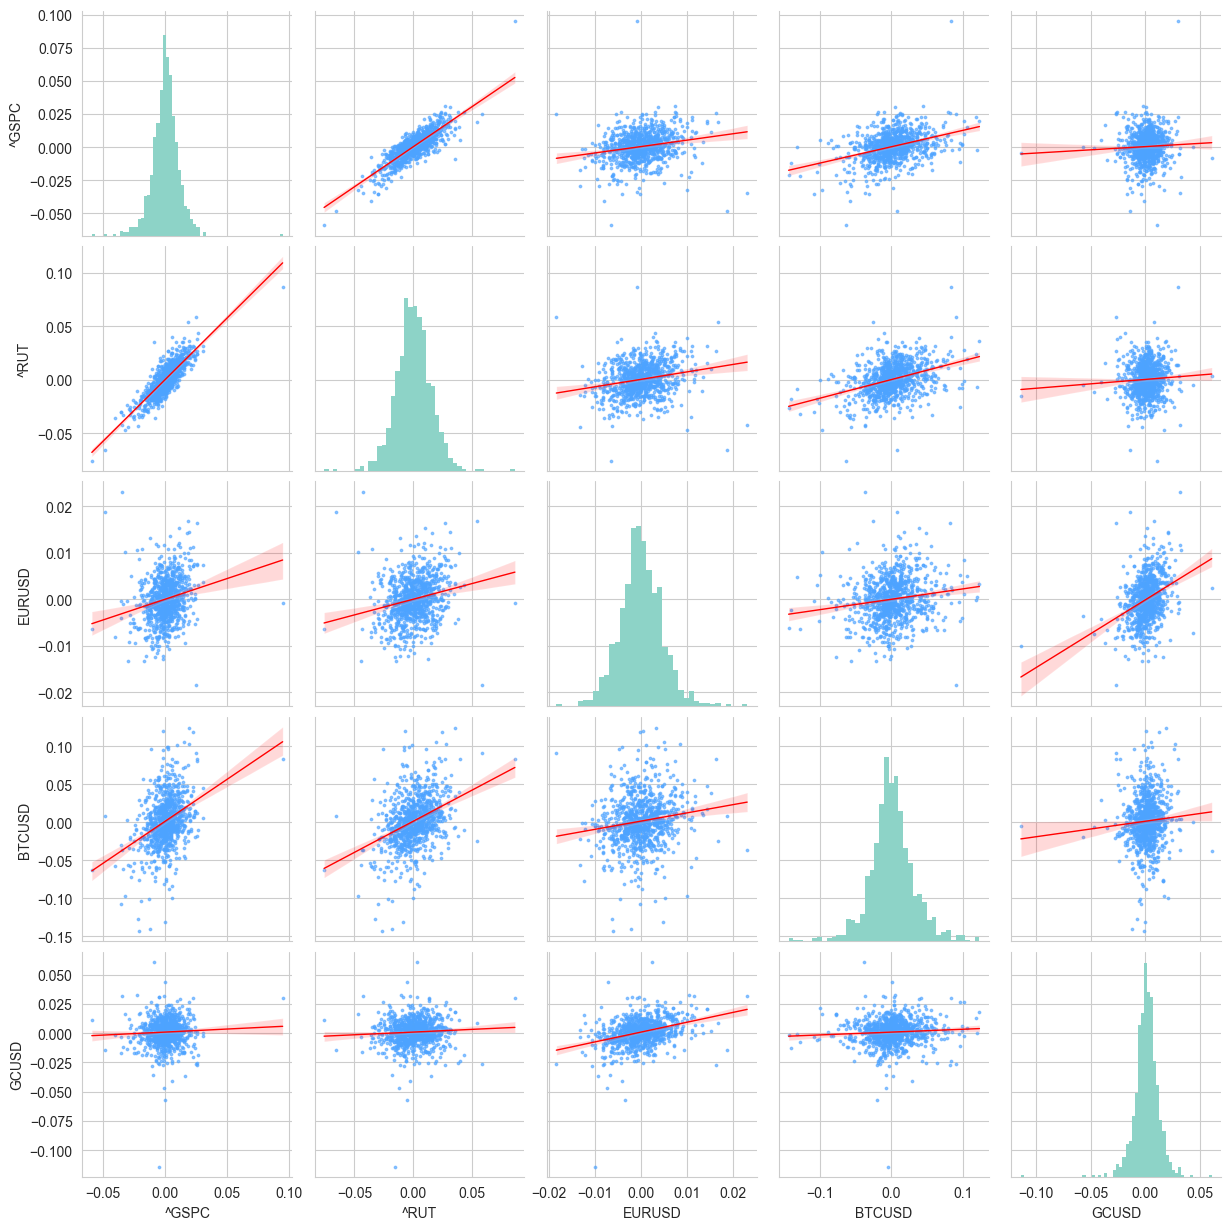

In [10]:
pl.price_change_distributions(returns_sel)